# Train

In [2]:
%load_ext autoreload
%autoreload 

In [3]:
import torch
import numpy as np
import xarray as xr
from pathlib import Path
import os
import random

import dask
from torch import nn

from hython.preprocess import apply_normalization
from hython.datasets.datasets import LSTMDataset
from hython.train_val import train_val
from hython.sampler import RegularIntervalSampler, DataLoaderSpatialSampler
from hython.metrics import mse_metric
from hython.losses import RMSELoss
from hython.utils import reclass,read_from_zarr, missing_location_idx, get_sampler_config, set_seed
from hython.models.lstm import CustomLSTM

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset

# viz
import matplotlib.pyplot as plt
from hython.viz import plot_sampler

/home/iferrario/.local/miniforge/envs/emulator/lib/python3.11/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/iferrario/.local/miniforge/envs/emulator/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Settings

In [4]:
WFLOW_MODEL =  "alps1km_eobs"
SURROGATE_MODEL = "alps1km_eobs"
EXP = "pathfrac"
SEED = 1696

dynamic_names = ["precip", "pet", "temp"] 
static_names = [ 'thetaS', 'thetaR', 'RootingDepth', 'Swood','KsatVer', "Sl"] 
target_names = [ "vwc","actevap"] 

# DL model hyper parameters
HIDDEN_SIZE = 24
INPUT_SIZE = len(dynamic_names)
OUTPUT_SIZE = len(target_names)
NUMBER_STATIC_PREDICTORS = len(static_names)
TARGET_WEIGHTS = {t:0.5 for t in target_names}

# train/val parameters

train_start = "2016-01-01"
train_end = "2018-12-31"
train_range = slice(train_start,train_end)

EPOCHS = 60
SPATIAL_BATCH_SIZE = 256
TEMPORAL_SAMPLING_SIZE = 150 
SEQ_LENGTH = 360 

# sampler parameters
#INTERVALS, TRAIN_ORIGIN, VAL_ORIGIN =  get_sampler_config(EXP)

# missing policy
remove_lakes = True

assert sum(v for v in TARGET_WEIGHTS.values()) == 1, "check target weights"
TARGET_INITIALS = "".join([i[0].capitalize() for i in target_names])

# paths
save_dir = Path("/mnt/CEPH_PROJECTS/InterTwin/Wflow/egu")
dp_surrogate_model = Path("/mnt/CEPH_PROJECTS/InterTwin/hydrologic_data/surrogate_model")
wd = Path("/mnt/CEPH_PROJECTS/InterTwin/hydrologic_data/surrogate_training")
surrogate_data = wd / f"{WFLOW_MODEL}.zarr"
input_dir_path = Path('/mnt/CEPH_PROJECTS/InterTwin/Wflow/models') / WFLOW_MODEL
fp_surrogate_model = dp_surrogate_model / f"{SURROGATE_MODEL}_{EXP}_v{TARGET_INITIALS}_h{HIDDEN_SIZE}_seed{SEED}.pt"

In [5]:
set_seed(SEED)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [6]:
# Read from preprocessed data, select train range

# train
Xd = read_from_zarr(url=surrogate_data, group="xd", multi_index="gridcell").sel(time = train_range).xd
Xs = read_from_zarr(url=surrogate_data, group="xs", multi_index="gridcell").xs
Y = read_from_zarr(url=surrogate_data, group="y", multi_index="gridcell").sel(time = train_range).y

# other 
wflow_lakes = Xs.sel(feat="wflow_lakeareas").unstack()
wflow_dem = Xs.sel(feat="wflow_dem").unstack()
wflow_landuse = Xs.sel(feat="wflow_landuse").unstack()

# select features and targets 
Xd = Xd.sel(feat=dynamic_names)
Xs = Xs.sel(feat=static_names)
Y = Y.sel(feat=target_names)

print(Xd.shape, Xs.shape, Y.shape)
# read masks
mask_missing = read_from_zarr(url=surrogate_data, group="mask" ).mask
mask_lake = read_from_zarr(url=surrogate_data, group="mask_lake" ).mask_lake

(810953, 1096, 3) (810953, 6) (810953, 1096, 2)


sampling rate 0.1 %
SamplerResult(
 - id_grid_2d: (689, 1177) 
 - idx_sampled_1d: (6741,) 
 - idx_sampled_1d_nomissing: (3080,)) 
 - idx_missing_1d: (438546,) 
 - sampled_grid_dims: (63, 107) 
 - xr_coords: None


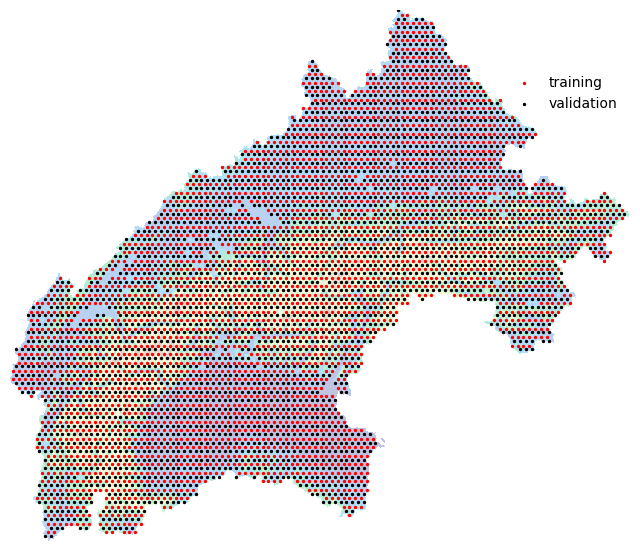

In [11]:
# Define the spatial samplers for both training and validation sets. Remeber the subsets should not overlap, so choose different origins.
INTERVALS, TRAIN_ORIGIN, VAL_ORIGIN =  get_sampler_config("s000100")
# training set
spatial_train_sampler = RegularIntervalSampler(intervals = INTERVALS, origin = TRAIN_ORIGIN)

# validation set
spatial_val_sampler = RegularIntervalSampler(intervals = INTERVALS, origin = VAL_ORIGIN) 

# Apply the samplers: return the cell indices that can be used later in training and validation to sample the whole spatial domain.
data2d  = wflow_dem.values[::-1]

idx = missing_location_idx(Xs.values)

sampler_train_meta = spatial_train_sampler.sampling_idx(data2d, mask_missing | mask_lake)
sampler_val_meta = spatial_val_sampler.sampling_idx(data2d, mask_missing | mask_lake)

# some useful metadata
print(sampler_train_meta)

# check location of training and validation sets
_ = plot_sampler(wflow_dem, sampler_train_meta, sampler_val_meta, figsize= (8, 8 ), markersize = 2)

## Stratified sampling

In [ ]:
# ### STRATIFIED SAMPLING
# ## ELEVATION
# # elevation
# dem_rec = reclass(wflow_dem, [0,500,1000,1500,2000,2500])
# dem_rec.plot(levels=6)

# #sampling 
# freq = 0.01

# dem_rec = dem_rec.where(~(mask_missing.compute() | mask_lake.compute())) # apply missing

# dem_rec.name = "wflow_dem"

# df = dem_rec[::-1].drop_vars(["spatial_ref","layer"]).to_dataframe().reset_index().drop(["lat","lon"], axis=1)

# from hython.sampler import get_grid_idx
# grid_idx = get_grid_idx(wflow_dem)

# df["grid_idx"] = grid_idx.flatten()

# df = df.dropna()

# tot_n = int(len(df)*freq)
# tot_n

# df.info()

# df.groupby("wflow_dem").count()["grid_idx"]

# n_class = df.groupby("wflow_dem").count()["grid_idx"].values
# n_class

# n_sample = int(tot_n/len(n_class))
# n_sample

# def sample_class(x):
#     x_len = len(x)
#     if x_len <= n_sample:
#         return x.sample(int(x_len*0.5))
#     else:
#         return x.sample(n_sample)
    

# df_train = df.groupby('wflow_dem', group_keys=False).apply(sample_class)

# len(df_train)

# diff = np.setdiff1d(df.grid_idx.values,df_train.grid_idx.values)

# df_remain = df.set_index("grid_idx").loc[diff].reset_index()

# df_val =  df_remain.groupby('wflow_dem', group_keys=False).apply(sample_class)

# sampler_train_meta.idx_sampled_1d_nomissing = df_train.grid_idx.values
# sampler_val_meta.idx_sampled_1d_nomissing = df_val.grid_idx.values
# sampler_train_meta.idx_sampled_1d_nomissing = df_train.grid_idx.values
# sampler_val_meta.idx_sampled_1d_nomissing = df_val.grid_idx.values



# # ELEVATION
# dem_rec = reclass(wflow_landuse, [100,200])
# dem_rec.plot(levels=3)

# #sampling 
# freq = 0.01

# dem_rec = dem_rec.where(~(mask_missing.compute() | mask_lake.compute())) # apply missing

# dem_rec.name = "wflow_landuse"

# df = dem_rec[::-1].drop_vars(["spatial_ref","layer"]).to_dataframe().reset_index().drop(["lat","lon"], axis=1)

# from hython.sampler import get_grid_idx
# grid_idx = get_grid_idx(wflow_dem)

# df["grid_idx"] = grid_idx.flatten()

# df = df.dropna()

# tot_n = int(len(df)*freq)
# tot_n

# df.info()

# df.groupby("wflow_landuse").count()["grid_idx"]

# n_class = df.groupby("wflow_landuse").count()["grid_idx"].values
# n_class

# n_sample = int(tot_n/len(n_class))
# n_sample

# def sample_class(x):
#     x_len = len(x)
#     if x_len <= n_sample:
#         return x.sample(int(x_len*0.5))
#     else:
#         return x.sample(n_sample)
    

# df_train = df.groupby('wflow_landuse', group_keys=False).apply(sample_class)

# len(df_train)

# diff = np.setdiff1d(df.grid_idx.values,df_train.grid_idx.values)

# df_remain = df.set_index("grid_idx").loc[diff].reset_index()

# df_val =  df_remain.groupby('wflow_landuse', group_keys=False).apply(sample_class)

# sampler_train_meta.idx_sampled_1d_nomissing = df_train.grid_idx.values
# sampler_val_meta.idx_sampled_1d_nomissing = df_val.grid_idx.values
# sampler_train_meta.idx_sampled_1d_nomissing = df_train.grid_idx.values
# sampler_val_meta.idx_sampled_1d_nomissing = df_val.grid_idx.values

In [18]:
print("Percentage of sampled data: ",(len(sampler_train_meta.idx_sampled_1d_nomissing)/ len(Xs[~idx].values.flatten()))*100, "%")

Percentage of sampled data:  0.11593836295031514 %


In [19]:
# # Normalizing

# statistics from training set
_, d_m, d_std = apply_normalization(Xd[sampler_train_meta.idx_sampled_1d_nomissing], type = "spacetime", how ='standard')
_, s_m, s_std = apply_normalization(Xs[sampler_train_meta.idx_sampled_1d_nomissing], type = "space", how ='standard')
_, y_m, y_std = apply_normalization(Y[sampler_train_meta.idx_sampled_1d_nomissing], type = "spacetime", how ='standard')

# normalize training set and validation set
Xd = apply_normalization(Xd, type="spacetime", how="standard", m1 = d_m, m2 = d_std).compute()
Xs = apply_normalization(Xs, type="space", how="standard",  m1 = s_m, m2 = s_std).compute()
Y = apply_normalization(Y, type="spacetime",how="standard", m1 = y_m, m2 = y_std).compute()

# Prepare Model inputs

In [20]:
Xs = torch.Tensor(Xs.values)
Xd = torch.Tensor(Xd.values)
Y = torch.Tensor(Y.values)

In [21]:
print(Xs.shape, Xd.shape, Y.shape)

# init datasets
dataset = LSTMDataset(Xd, Y, Xs)

train_sampler = DataLoaderSpatialSampler(dataset, num_samples=1, sampling_indices = sampler_train_meta.idx_sampled_1d_nomissing.tolist())
valid_sampler = DataLoaderSpatialSampler(dataset, num_samples=1, sampling_indices = sampler_val_meta.idx_sampled_1d_nomissing.tolist())

train_loader = DataLoader(dataset, batch_size=SPATIAL_BATCH_SIZE, shuffle=False, sampler = train_sampler) # implement shuffling in the sampler!
val_loader = DataLoader(dataset, batch_size=SPATIAL_BATCH_SIZE, shuffle=False, sampler = valid_sampler)

torch.Size([810953, 7]) torch.Size([810953, 1096, 3]) torch.Size([810953, 1096, 2])


In [22]:
a,_,_ = next(iter(train_loader))

# Initialize Model

In [31]:
model = CustomLSTM(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE, NUMBER_STATIC_PREDICTORS)
model = model.to(device)
model

CustomLSTM(
  (fc0): Linear(in_features=10, out_features=36, bias=True)
  (lstm): LSTM(36, 36, batch_first=True)
  (fc1): Linear(in_features=36, out_features=2, bias=True)
)

# Train/valid settings

In [32]:
path2models= "./checkpoints" 
if not os.path.exists(path2models):
    os.mkdir(path2models)
    
    
opt = optim.Adam(model.parameters(), lr=1e-3)


loss_fn = RMSELoss(target_weight=TARGET_WEIGHTS)


metric_fn = mse_metric

lr_scheduler = ReduceLROnPlateau(opt, mode='min',factor=0.5, patience=10)


In [33]:
params_train={
    "num_epochs": EPOCHS,
    "temporal_sampling_idx_change_with_epoch": True,
    "temporal_sampling_size": TEMPORAL_SAMPLING_SIZE,
    "seq_length": SEQ_LENGTH,
    "ts_range": Y.shape[1],
    "optimizer": opt,
    "loss_func": loss_fn,
    "metric_func": metric_fn,
    "train_dl": train_loader, 
    "val_dl": val_loader,
    "lr_scheduler": lr_scheduler,
    "path2weights": f"{path2models}/weights.pt",
    "device":device,
    "target_names": target_names

}

# Run Train/valid

In [34]:
model, sm_loss_history, sm_metric_history = train_val(model, params_train)

  0%|                                                                                                         | 0/60 [00:00<?, ?it/s]

Epoch 0/59, current lr=0.001


  2%|█▌                                                                                               | 1/60 [00:18<18:13, 18.53s/it]

Copied best model weights!
train loss: 0.25692957639694214, train metric: {'vwc': 0.2504971, 'actevap': 0.23847145}
val loss: 0.32357823848724365, val metric: {'vwc': 0.45399982, 'actevap': 0.39115933}
----------
Epoch 1/59, current lr=0.001


  3%|███▏                                                                                             | 2/60 [00:37<17:55, 18.54s/it]

...

train loss: 0.1554124504327774, train metric: {'vwc': 0.1258095, 'actevap': 0.07269695}
val loss: 0.17469769716262817, val metric: {'vwc': 0.16682035, 'actevap': 0.09689635}
----------
Epoch 58/59, current lr=0.0005


 98%|██████████████████████████████████████████████████████████████████████████████████████████████▍ | 59/60 [18:23<00:18, 18.53s/it]

Copied best model weights!
train loss: 0.14849229156970978, train metric: {'vwc': 0.12216004, 'actevap': 0.053770397}
val loss: 0.1695646196603775, val metric: {'vwc': 0.16734096, 'actevap': 0.07538131}
----------
Epoch 59/59, current lr=0.0005


100%|████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [18:41<00:00, 18.69s/it]

train loss: 0.15352179110050201, train metric: {'vwc': 0.112917505, 'actevap': 0.07413433}
val loss: 0.17319302260875702, val metric: {'vwc': 0.15639058, 'actevap': 0.09515854}
----------


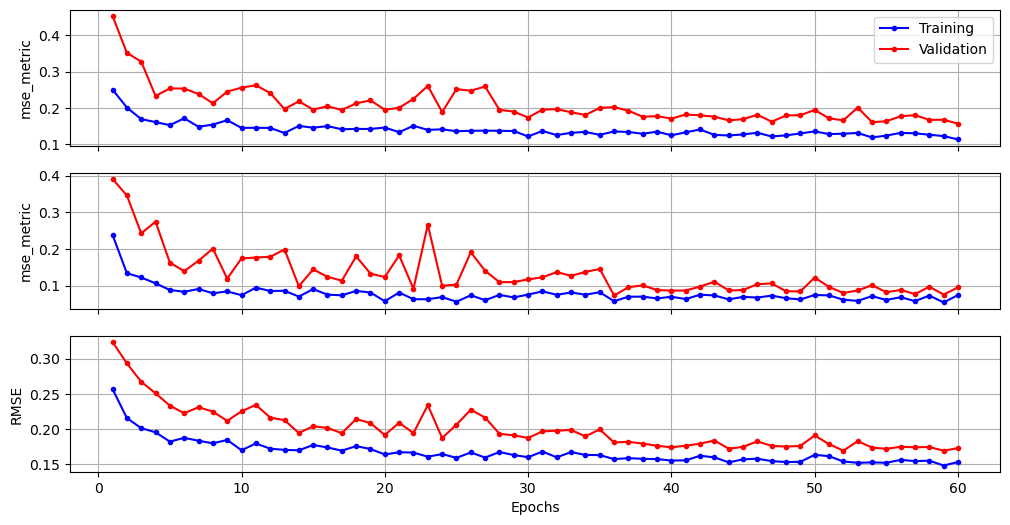

In [35]:
lepochs = list(range(1,params_train["num_epochs"] + 1))

fig, axs = plt.subplots(3, 1, figsize= (12,6), sharex=True)

axs[0].plot(lepochs, sm_metric_history['train_vwc'], marker='.', linestyle='-', color='b', label='Training')
axs[0].plot(lepochs, sm_metric_history['val_vwc'], marker='.', linestyle='-', color='r', label='Validation')
#axs[0].title('Validation Loss - SM')
axs[0].set_ylabel(metric_fn.__name__)
axs[0].grid(True)
axs[0].legend(bbox_to_anchor=(1,1))

axs[1].plot(lepochs, sm_metric_history['train_actevap'], marker='.', linestyle='-', color='b', label='Training')
axs[1].plot(lepochs, sm_metric_history['val_actevap'], marker='.', linestyle='-', color='r', label='Validation')
#axs[0].title('Validation Loss - SM')
axs[1].set_ylabel(metric_fn.__name__)
axs[1].grid(True)

axs[2].plot(lepochs, [i.detach().cpu().numpy() for i in sm_loss_history['train']], marker='.', linestyle='-', color='b', label='Training')
axs[2].plot(lepochs, [i.detach().cpu().numpy() for i in sm_loss_history['val']], marker='.', linestyle='-', color='r', label='Validation')
#axs[0].title('Validation Loss - SM')
axs[2].set_xlabel('Epochs')
axs[2].set_ylabel(loss_fn.__name__)
axs[2].grid(True)

In [37]:
# save model
torch.save(model.state_dict(), fp_surrogate_model)

In [36]:
fp_surrogate_model

PosixPath('/mnt/CEPH_PROJECTS/InterTwin/hydrologic_data/surrogate_model/alps1km_eobs_pathfrac_vVA_h36_seed1696.pt')